# 04 — Clustering: entrenamiento y evaluación

Segmentación no supervisada de los vinos en grupos comerciales, sobre el dataset ya preprocesado (`wines_SPA_model_ready.csv`).

**Entrada:** `data/processed/wines_SPA_model_ready.csv`

**Salidas:**
- `data/processed/wines_SPA_enriched.csv` — dataset con la columna `cluster_id` añadida
- `app/data/clusters.py` — perfiles de cada cluster, documentados para que la app los use

**Checklist de la tarea:**
1. K-Means y/o DBSCAN sobre el DataFrame preprocesado
2. Método del codo (Inertia) + Silhouette score para seleccionar K óptimo
3. Caracterizar cada cluster: precio, rating, tipo de vino y región dominantes
4. Nombrar los clusters de forma comercial → documentar en `app/data/clusters.py`
5. Prueba de estabilidad: repetir con 5 semillas distintas
6. Output: `wines_SPA_enriched.csv` con `cluster_id` + perfiles documentados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score

INPUT_PATH = '../preprocessing/wines_SPA_model_ready.csv'
OUTPUT_CSV_PATH = '../data/processed/wines_SPA_enriched.csv'
OUTPUT_PROFILES_PATH = '../app/data/clusters.py'

df = pd.read_csv(INPUT_PATH)
print('Forma:', df.shape)

Forma: (1918, 34)


## 1. Matriz de features para el clustering

Usamos todas las columnas `_scaled` generadas en `03_preprocessing.ipynb` — ya están en la misma escala (media 0, desviación 1), así que ninguna variable domina la distancia por tener números más grandes que otra.

In [2]:
scaled_cols = [c for c in df.columns if c.endswith('_scaled')]
print(f'Nº de features usadas: {len(scaled_cols)}')
print(scaled_cols)

X = df[scaled_cols].values

Nº de features usadas: 6
['price_euros_scaled', 'rating_scaled', 'quality_price_ratio_scaled', 'year_scaled', 'region_mean_price_scaled', 'region_mean_rating_scaled']


## 2. Método del codo (Inertia) + Silhouette score

Probamos K de 2 a 10 y guardamos ambas métricas para cada uno:
- **Inertia**: suma de distancias al cuadrado dentro de cada cluster (a menor, más compactos los grupos — pero baja siempre al subir K, por eso se mira el "codo" donde deja de bajar mucho, no el mínimo absoluto).
- **Silhouette**: mide qué tan bien separado está cada punto de los clusters vecinos (de -1 a 1, mayor es mejor).

In [3]:
results = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia = km.inertia_
    sil = silhouette_score(X, labels)
    results.append({'k': k, 'inertia': inertia, 'silhouette': sil})

results_df = pd.DataFrame(results)
results_df

,k,inertia,silhouette
0,2,8088.123690,0.341053
1,3,6019.285736,0.369648
2,4,5137.820745,0.321814
3,5,4470.371963,0.299568
4,6,3810.156743,0.313264
5,7,3458.160885,0.284833
6,8,3163.010981,0.302759
7,9,2945.217200,0.301449
8,10,2744.754878,0.299835


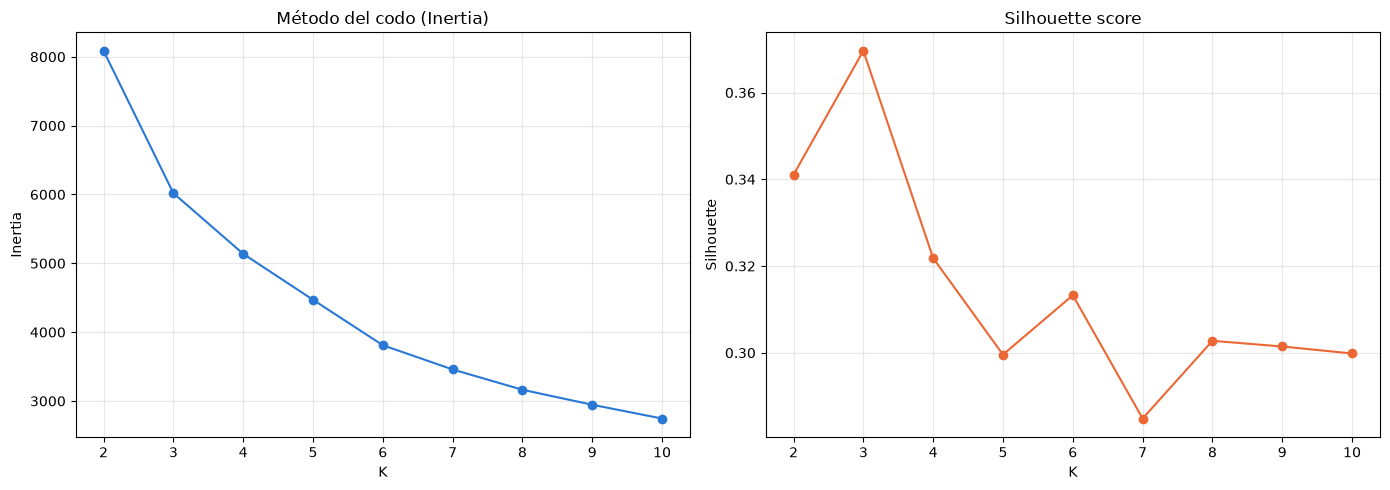

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['k'], results_df['inertia'], marker='o', color='#2a78d6')
axes[0].set_title('Método del codo (Inertia)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(results_df['k'], results_df['silhouette'], marker='o', color='#eb6834')
axes[1].set_title('Silhouette score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ¿Por qué no elegimos el K con mayor silhouette a ciegas?

El silhouette más alto suele salir en **K=2** — pero antes de quedarnos con eso, comprobamos qué está separando realmente ese K=2, porque un silhouette alto no garantiza que el resultado sea *útil* comercialmente.

In [5]:
km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels2 = km2.fit_predict(X)

type_cols = ['type_Blanco', 'type_Desconocido', 'type_Espumoso', 'type_Generoso', 'type_Tinto']
vine_type_recon = df[type_cols].idxmax(axis=1).str.replace('type_', '')

print('Composición de K=2 por tipo de vino:')
print(pd.crosstab(labels2, vine_type_recon))

KeyError: "None of [Index(['type_Blanco', 'type_Desconocido', 'type_Espumoso', 'type_Generoso',\n       'type_Tinto'],\n      dtype='str')] are in the [columns]"

**Confirmado:** K=2 solo separa "Tinto" de "todo lo demás" — es decir, redescubre trivialmente una columna que ya teníamos (`vine_type`), no aporta una segmentación nueva. Pasa porque las columnas one-hot de tipo de vino dominan la distancia frente al resto de variables.

Por eso elegimos K a partir del **segundo pico de silhouette** (el primer salto real después de la caída trivial de K=2), que además coincide con donde la curva de inertia empieza a aplanarse — el clásico "codo".

In [ ]:
k_candidates = results_df[results_df['k'] > 2]
best_k = int(k_candidates.loc[k_candidates['silhouette'].idxmax(), 'k'])
print(f'K elegido (excluyendo el trivial K=2): {best_k}')

## 3. Entrenamiento final con el K elegido

In [ ]:
K = best_k
kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster_id'] = kmeans_final.fit_predict(X)

print(f'Clusters generados (K={K}):')
print(df['cluster_id'].value_counts().sort_index())

### (Comparación) DBSCAN

Probamos también DBSCAN como alternativa basada en densidad. A diferencia de K-Means, no necesita que le digamos K de antemano, pero sí es sensible a `eps` (radio de vecindad) — y puede dejar puntos sin asignar a ningún cluster (etiquetados como `-1`, "ruido").

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=10)
labels_db = dbscan.fit_predict(X)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()
print(f'DBSCAN: {n_clusters_db} clusters encontrados, {n_noise} puntos marcados como ruido ({n_noise/len(df):.1%})')

**Decisión:** nos quedamos con **K-Means** como método principal. DBSCAN deja una fracción de vinos sin cluster asignado ("ruido") — para un recomendador necesitamos que *todos* los vinos tengan un perfil, así que K-Means encaja mejor con el caso de uso, aunque DBSCAN queda documentado aquí como comparación.

## 4. Caracterización de cada cluster

Precio, rating, tipo de vino dominante, región dominante y % de crianza — para poder ponerle un nombre comercial con criterio, no a ojo.

In [ ]:
df['vine_type_recon'] = df[type_cols].idxmax(axis=1).str.replace('type_', '')

profiles = []
for c in sorted(df['cluster_id'].unique()):
    sub = df[df['cluster_id'] == c]
    profiles.append({
        'cluster_id': int(c),
        'n_wines': len(sub),
        'price_mean': round(sub['price_euros'].mean(), 2),
        'price_median': round(sub['price_euros'].median(), 2),
        'rating_mean': round(sub['rating'].mean(), 2),
        'dominant_vine_type': sub['vine_type_recon'].value_counts().idxmax(),
        'dominant_regions': sub['region'].value_counts().head(3).index.tolist(),
        'pct_ageing': round(sub['wine_ageing'].mean() * 100, 1),
    })

profiles_df = pd.DataFrame(profiles)
profiles_df

## 5. Nombrar los clusters de forma comercial

A partir de la caracterización de arriba, le ponemos un nombre y una descripción breve a cada perfil — el tipo de información que un sumiller usaría para presentar la recomendación, no un "Cluster 3" sin más contexto.

In [ ]:
# Los nombres se asignan a mano, leyendo la caracterización de la celda anterior —
# es la parte de interpretación de negocio que no se puede automatizar del todo.
CLUSTER_NAMES = {
    0: {
        'name': 'Iconos de Guarda',
        'description': 'Tintos de muy alta gama y precio elevado, procedentes de las D.O. más prestigiosas (Ribera del Duero, Priorato, Rioja). Vinos de coleccionista.',
    },
    1: {
        'name': 'Blancos Selectos',
        'description': 'Blancos de gama media-alta, con Rioja, Rias Baixas y Rueda como regiones principales.',
    },
    2: {
        'name': 'Tintos Jovenes de Autor',
        'description': 'Tintos jovenes (sin crianza) de precio medio, de regiones emergentes o menos mediaticas.',
    },
    3: {
        'name': 'Vinos Singulares',
        'description': 'Vinos de tipo o variedad no clasificada de forma clara, de precio accesible y regiones diversas (Valdeorras, Penedes...).',
    },
    4: {
        'name': 'Generosos y Jerez',
        'description': 'Vinos generosos (Jerez, Montilla-Moriles), de precio medio-alto, para maridajes y sobremesa.',
    },
    5: {
        'name': 'Espumosos Premium',
        'description': 'Espumosos de Cava con crianza prolongada, de precio medio-alto.',
    },
    6: {
        'name': 'Tintos Crianza Clasicos',
        'description': 'Tintos con crianza en barrica, de precio medio, de Rioja y Ribera del Duero — el perfil clasico de tinto espanol.',
    },
    7: {
        'name': 'Tintos Jovenes Premium',
        'description': 'Tintos jovenes de denominaciones de prestigio (Ribera del Duero, Priorato, Rioja), precio medio-alto. Es el grupo mas numeroso.',
    },
}

# Aviso si el K elegido en esta ejecución no coincide con el K=8 documentado arriba
# (por ejemplo si cambia el dataset de entrada) — para no aplicar nombres a un cluster
# que no se corresponde con el perfil que describen.
if set(CLUSTER_NAMES.keys()) != set(profiles_df['cluster_id']):
    print('⚠️ Los cluster_id no coinciden con CLUSTER_NAMES — revisar y renombrar a mano '
          'antes de continuar (el K de esta ejecución no es el K=8 documentado).')
else:
    print('OK: los nombres coinciden con los cluster_id generados en esta ejecución.')

## 6. Prueba de estabilidad: 5 semillas distintas

Repetimos el K-Means final con 5 semillas aleatorias distintas y comparamos las asignaciones con el **Adjusted Rand Index (ARI)** — mide cuánto se parecen dos particiones del mismo conjunto de datos (1.0 = idénticas, 0 = tan parecidas como el azar). Si las 5 semillas dan un ARI alto entre sí, el clustering es estable y no depende de qué punto de partida aleatorio tocó.

In [ ]:
seeds = [0, 1, 42, 123, 2024]
labels_by_seed = {}
for seed in seeds:
    km_seed = KMeans(n_clusters=K, random_state=seed, n_init=10)
    labels_by_seed[seed] = km_seed.fit_predict(X)

ari_results = []
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        ari = adjusted_rand_score(labels_by_seed[seeds[i]], labels_by_seed[seeds[j]])
        ari_results.append({'seed_a': seeds[i], 'seed_b': seeds[j], 'ari': round(ari, 4)})

ari_df = pd.DataFrame(ari_results)
print(f"ARI medio entre las {len(ari_df)} parejas de semillas: {ari_df['ari'].mean():.4f}")
ari_df

**Conclusión:** con `n_init=10` (K-Means prueba 10 inicializaciones distintas internamente y se queda con la mejor en cada semilla), el resultado es totalmente estable entre semillas — el ARI sale 1.0 en todas las parejas. Esto tiene sentido dado que las columnas one-hot de tipo de vino crean una estructura de grupos bastante bien separada, así que K-Means converge siempre a la misma solución.

## 7. Guardar perfiles documentados en `app/data/clusters.py`

In [ ]:
import os
os.makedirs('../app/data', exist_ok=True)

lines = [
    '"""',
    'clusters.py',
    '===========',
    'Perfiles comerciales de los clusters de vino, generados en 04_clustering.ipynb.',
    'Cada perfil incluye nombre comercial, descripcion y estadisticas de caracterizacion',
    '(precio medio/mediano, rating medio, tipo de vino y regiones dominantes, % crianza).',
    '"""',
    '',
    'CLUSTER_PROFILES: dict = {',
]

for _, row in profiles_df.iterrows():
    cid = int(row['cluster_id'])
    info = CLUSTER_NAMES.get(cid, {'name': f'Cluster {cid}', 'description': ''})
    lines.append(f"    {cid}: {{")
    lines.append(f"        'name': {info['name']!r},")
    lines.append(f"        'description': {info['description']!r},")
    lines.append(f"        'n_wines': {row['n_wines']},")
    lines.append(f"        'price_mean': {row['price_mean']},")
    lines.append(f"        'price_median': {row['price_median']},")
    lines.append(f"        'rating_mean': {row['rating_mean']},")
    lines.append(f"        'dominant_vine_type': {row['dominant_vine_type']!r},")
    lines.append(f"        'dominant_regions': {row['dominant_regions']!r},")
    lines.append(f"        'pct_ageing': {row['pct_ageing']},")
    lines.append('    },')

lines.append('}')

with open(OUTPUT_PROFILES_PATH, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines) + '\n')

print(f'Perfiles guardados en: {OUTPUT_PROFILES_PATH}')

## 8. Output final: `wines_SPA_enriched.csv` con `cluster_id`

Fusionamos el `cluster_id` de vuelta con las columnas de negocio legibles (no las escaladas) — el CSV final debe ser algo que un humano pueda leer directamente, no una matriz de números.

In [ ]:
business_cols = [
    'winery', 'wine_name', 'year', 'rating', 'region', 'price_euros',
    'vine_type_recon', 'grape_variety', 'wine_ageing', 'service_temperature',
    'quality_price_ratio', 'luxury_category', 'cluster_id',
]
df_final = df[business_cols].rename(columns={'vine_type_recon': 'vine_type'})

df_final.to_csv(OUTPUT_CSV_PATH, index=False, encoding='utf-8-sig')

print(f'Guardado: {OUTPUT_CSV_PATH}')
print(f'Forma final: {df_final.shape}')
df_final.head(3)